In [ ]:
# Shared setup: clone/refresh the repo, switch to the demo branch, mount Drive, and install dependencies.
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

BRANCH_NAME = 'codex/colab-sweep-workflow'
repo_dir = Path('/content/KVCompass')
if not repo_dir.exists():
    !git clone https://github.com/AarnavSawant/KVCompass.git /content/KVCompass

%cd /content/KVCompass
!git fetch origin
!git checkout "$BRANCH_NAME"
!git pull origin "$BRANCH_NAME"
!nvidia-smi
!python -m pip install --upgrade pip
!pip install -r requirements.txt
!pip install -e .


Mounted at /content/drive
Cloning into '/content/KVCompass'...
remote: Enumerating objects: 233, done.
remote: Counting objects: 100% (233/233), done.
remote: Compressing objects: 100% (150/150), done.
remote: Total 233 (delta 107), reused 189 (delta 70), pack-reused 0 (from 0)
Receiving objects: 100% (233/233), 866.55 KiB | 14.44 MiB/s, done.
Resolving deltas: 100% (107/107), done.
/content/KVCompass
Branch 'codex/colab-sweep-workflow' set up to track remote branch 'codex/colab-sweep-workflow' from 'origin'.
Switched to a new branch 'codex/colab-sweep-workflow'
From https://github.com/AarnavSawant/KVCompass
 * branch            codex/colab-sweep-workflow -> FETCH_HEAD
Already up to date.
Fri Apr 17 17:02:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+------------------

In [ ]:
# Shared values used by all run cells.
from pathlib import Path

SHARED_RESULTS_DIR = Path('/content/drive/MyDrive/KVCompass')
SHARED_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print('Shared results dir:', SHARED_RESULTS_DIR)


Shared results dir: /content/drive/MyDrive/KVCompass


In [ ]:
# Load and combine the benchmark assignment summaries.
import json
from pathlib import Path
import pandas as pd

summary_root = SHARED_RESULTS_DIR / 'benchmark_eval'
summary_paths = [summary_root / f'assignment_{i}__summary.csv' for i in range(1, 6) if (summary_root / f'assignment_{i}__summary.csv').exists()]
combined_summary = pd.concat([pd.read_csv(path) for path in summary_paths], ignore_index=True) if summary_paths else pd.DataFrame()
combined_summary = combined_summary.dropna()
print('Summary files:', [str(path) for path in summary_paths])
display(combined_summary)

if not combined_summary.empty:
    rows = []
    for _, row in combined_summary.iterrows():
        metrics = json.loads(Path(row['metrics_path']).read_text())
        metric_values = []
        for task_metrics in metrics.values():
            if isinstance(task_metrics, dict):
                metric_values.extend(v for v in task_metrics.values() if isinstance(v, (int, float)))
        rows.append({
            'scenario_name': row['scenario_name'],
            'dataset': row['dataset'],
            'data_dir': row['data_dir'],
            'task_prefixes': row['task_prefixes'],
            'method': row['method'],
            'budget': row['budget'],
            'avg_quality': round(sum(metric_values) / len(metric_values), 2) if metric_values else None,
            'avg_latency_seconds': row.get('avg_latency_seconds'),
            'avg_throughput_tokens_per_second': row.get('avg_throughput_tokens_per_second'),
            'peak_gpu_memory_mb': row.get('peak_gpu_memory_mb'),
        })
    leaderboard = pd.DataFrame(rows).sort_values(['task_prefixes', 'scenario_name', 'avg_quality', 'avg_latency_seconds'], ascending=[True, True, False, True])
    display(leaderboard)
else:
    print('No assignment summaries found yet.')


Summary files: ['/content/drive/MyDrive/KVCompass/benchmark_eval/assignment_1__summary.csv', '/content/drive/MyDrive/KVCompass/benchmark_eval/assignment_2__summary.csv', '/content/drive/MyDrive/KVCompass/benchmark_eval/assignment_3__summary.csv', '/content/drive/MyDrive/KVCompass/benchmark_eval/assignment_4__summary.csv', '/content/drive/MyDrive/KVCompass/benchmark_eval/assignment_5__summary.csv']


,scenario_name,dataset,data_dir,task_prefixes,model,method,budget,predictions_path,metrics_path,avg_latency_seconds,avg_throughput_tokens_per_second,peak_gpu_memory_mb
0,needle_in_a_haystack_4k,ruler,4096,niah,Qwen/Qwen3-8B,snapkv,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,3.420993,15.018375,16398.09033
1,needle_in_a_haystack_4k,ruler,4096,niah,Qwen/Qwen3-8B,expected_attention,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,2.619632,12.868609,16398.69775
2,needle_in_a_haystack_4k,ruler,4096,niah,Qwen/Qwen3-8B,knorm,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,2.416859,14.028300,16397.60596
3,needle_in_a_haystack_4k,ruler,4096,niah,Qwen/Qwen3-8B,tova,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,2.613547,13.723594,16397.60596
4,needle_in_a_haystack_4k,ruler,4096,niah,Qwen/Qwen3-8B,streaming_llm,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,3.066988,14.660233,16397.60596
...,...,...,...,...,...,...,...,...,...,...,...,...
67,aggregation_16k,ruler,16384,"cwe,fwe",Qwen/Qwen3-8B,snapkv,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,5.161916,9.431863,19491.30420
68,aggregation_16k,ruler,16384,"cwe,fwe",Qwen/Qwen3-8B,expected_attention,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,6.136360,9.908813,19491.30420
69,aggregation_16k,ruler,16384,"cwe,fwe",Qwen/Qwen3-8B,knorm,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,4.857968,9.589446,19491.30420
70,aggregation_16k,ruler,16384,"cwe,fwe",Qwen/Qwen3-8B,tova,0.5,/content/drive/MyDrive/KVCompass/benchmark_eva...,/content/drive/MyDrive/KVCompass/benchmark_eva...,4.923134,9.287782,19491.30420


,scenario_name,dataset,data_dir,task_prefixes,method,budget,avg_quality,avg_latency_seconds,avg_throughput_tokens_per_second,peak_gpu_memory_mb
70,aggregation_16k,ruler,16384,"cwe,fwe",tova,0.5,87.91,4.923134,9.287782,19491.30420
67,aggregation_16k,ruler,16384,"cwe,fwe",snapkv,0.5,83.85,5.161916,9.431863,19491.30420
71,aggregation_16k,ruler,16384,"cwe,fwe",streaming_llm,0.5,81.66,5.934074,10.467635,19491.30420
69,aggregation_16k,ruler,16384,"cwe,fwe",knorm,0.5,80.33,4.857968,9.589446,19491.30420
68,aggregation_16k,ruler,16384,"cwe,fwe",expected_attention,0.5,62.28,6.136360,9.908813,19491.30420
...,...,...,...,...,...,...,...,...,...,...
39,multi_hop_tracing_8k,ruler,8192,vt,streaming_llm,0.5,61.44,2.153216,12.247368,16992.84473
37,multi_hop_tracing_8k,ruler,8192,vt,knorm,0.5,57.76,2.152839,12.261424,16992.84473
55,vt_16k_baseline,ruler,16384,vt,no_compression,1.0,100.00,2.578023,6.117942,19586.41357
49,vt_4k_baseline,ruler,4096,vt,no_compression,1.0,100.00,1.190860,13.117454,16563.62988


In [ ]:
leaderboard["scenario_name"] = leaderboard["scenario_name"].replace(
        {'aggregation_4k_baseline': 'aggregation_4k',
         'aggregation_8k_baseline': 'aggregation_8k',
         'niah_4k_baseline': 'needle_in_a_haystack_4k',
         'niah_8k_baseline': 'needle_in_a_haystack_8k',
         'qa_4k_baseline': 'question_answering_4k',
         'qa_8k_baseline': 'question_answering_8k',
         'vt_4k_baseline': 'multi_hop_tracing_4k',
         'vt_8k_baseline': 'multi_hop_tracing_8k',
         'aggregation_16k_baseline': 'aggregation_16k',
         'niah_16k_baseline': 'needle_in_a_haystack_16k',
         'qa_16k_baseline': 'question_answering_16k',
         'vt_16k_baseline': 'multi_hop_tracing_16k',
         })
desired_order = ['no_compression', 'expected_attention', 'knorm', 'snapkv', 'streaming_llm', 'tova']

In [ ]:
# Build a presentation-friendly matrix view QUALITY SCORE.

if 'leaderboard' in globals() and not leaderboard.empty:
    quality = leaderboard.pivot_table(
        index=['scenario_name', 'data_dir'],
        columns='method',
        values='avg_quality',
        aggfunc='first',
    )
    quality = quality.reindex(columns=desired_order)
    display(quality)
else:
    print('Leaderboard not ready yet.')


,method,no_compression,expected_attention,knorm,snapkv,streaming_llm,tova
scenario_name,data_dir,,,,,,
aggregation_16k,16384,86.00,62.28,80.33,83.85,81.66,87.91
aggregation_4k,4096,96.56,95.61,86.12,96.09,95.28,86.14
aggregation_8k,8192,93.19,82.91,81.65,92.44,87.02,86.72
multi_hop_tracing_16k,16384,100.00,100.00,60.00,99.20,50.80,100.00
multi_hop_tracing_4k,4096,100.00,88.96,56.48,83.20,55.20,100.00
multi_hop_tracing_8k,8192,100.00,97.28,57.76,87.52,61.44,100.00
needle_in_a_haystack_16k,16384,98.61,33.66,70.76,55.98,47.05,71.88
needle_in_a_haystack_4k,4096,99.97,35.71,76.09,42.02,49.04,75.73
needle_in_a_haystack_8k,8192,99.79,44.00,76.69,45.78,54.54,77.05


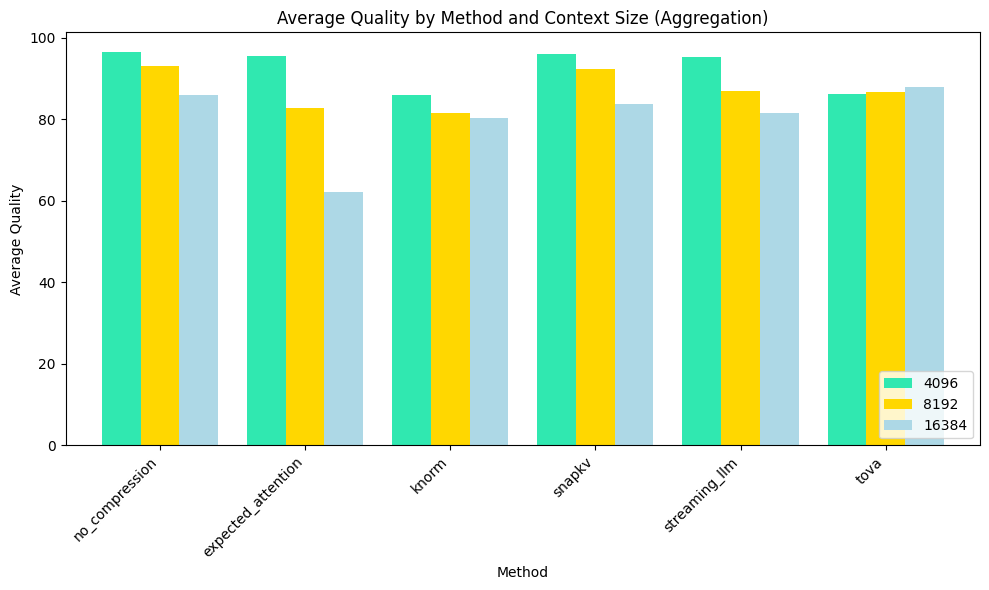

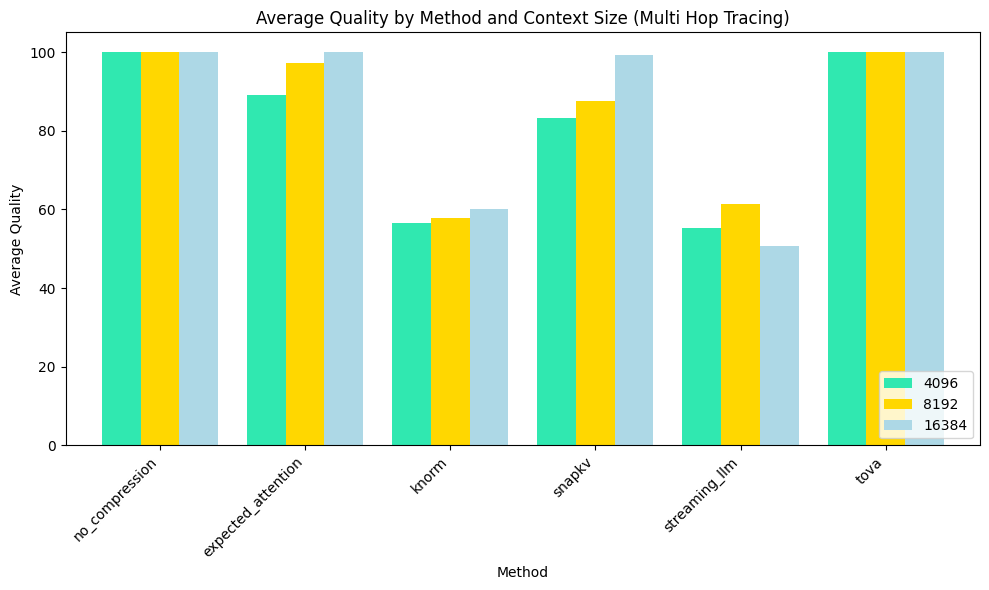

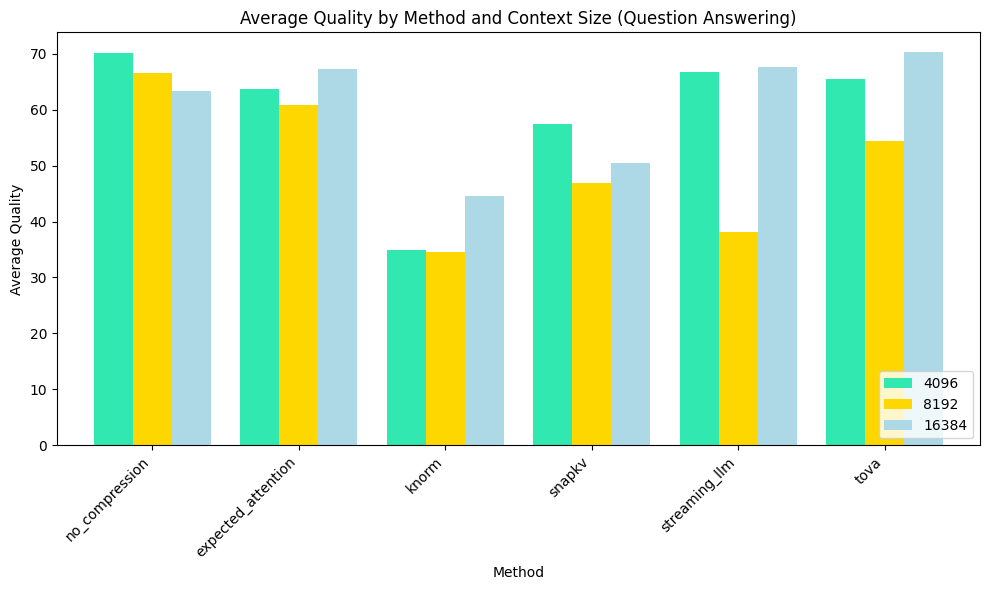

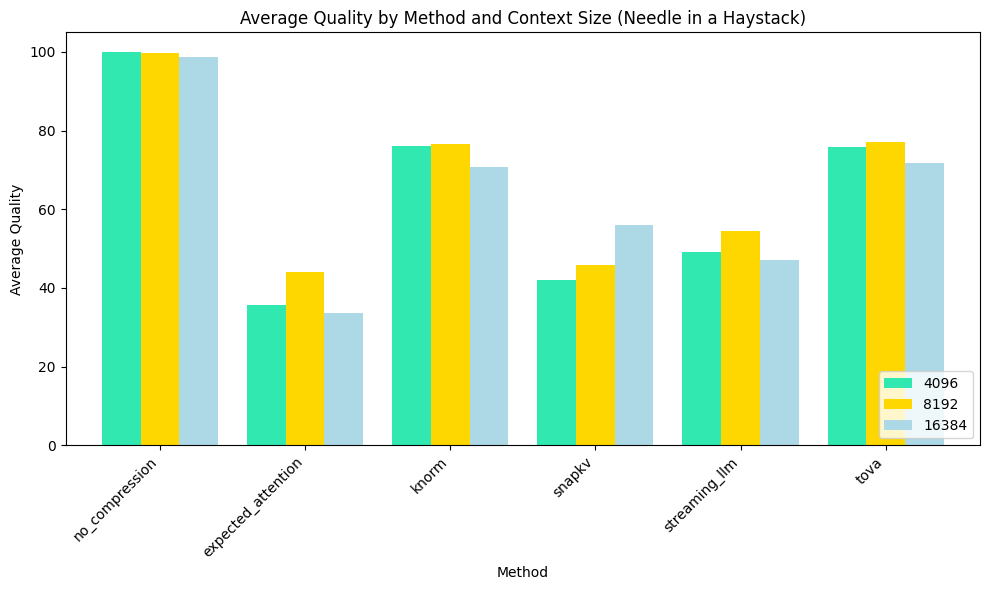

In [ ]:
import matplotlib.pyplot as plt

all_tasks = ['cwe,fwe', 'vt', 'qa', 'niah']
task_map = {
    'cwe,fwe': "Aggregation",
    'vt': "Multi Hop Tracing",
    'qa': "Question Answering",
    'niah': "Needle in a Haystack"
}

all_data = leaderboard.loc[:, ["avg_quality", "method", "task_prefixes", "data_dir"]]

for task in all_tasks:
    test = all_data[all_data["task_prefixes"] == task]
    test = test.sort_values(by=['method', 'data_dir'])


    pivot_df = test.pivot(
        index="method",
        columns="data_dir",
        values="avg_quality"
    )

    pivot_df = pivot_df.reindex(desired_order)


    ax = pivot_df.plot(
        kind="bar",
        color=["#30E8B0", "#FFD700", "#ADD8E6"],
        figsize=(10, 6),
        width=0.8
    )


    ax.set_xlabel("Method")
    ax.set_ylabel("Average Quality")
    ax.set_title("Average Quality by Method and Context Size (" + task_map[task] + ")")
    ax.legend(title="Context Size")



    plt.xticks(rotation=45, ha="right")
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

In [ ]:
# Build a presentation-friendly matrix view LATENCY.

if 'leaderboard' in globals() and not leaderboard.empty:
    latency = leaderboard.pivot_table(
        index=['scenario_name', 'data_dir'],
        columns='method',
        values='avg_latency_seconds',
        aggfunc='first',
    )
    latency = latency.reindex(columns=desired_order)
    display(latency)
else:
    print('Leaderboard not ready yet.')


,method,no_compression,expected_attention,knorm,snapkv,streaming_llm,tova
scenario_name,data_dir,,,,,,
aggregation_16k,16384,5.630209,6.136360,4.857968,5.161916,5.934074,4.923134
aggregation_4k,4096,2.268296,2.995956,2.721217,2.781968,4.155346,3.180540
aggregation_8k,8192,2.657291,4.187395,3.288349,3.282966,4.641843,3.015283
multi_hop_tracing_16k,16384,2.578023,2.792693,3.109683,2.627795,3.071968,2.582642
multi_hop_tracing_4k,4096,1.190860,1.330562,1.719120,1.387352,1.805873,1.242029
multi_hop_tracing_8k,8192,1.588313,1.774551,2.152839,1.685497,2.153216,1.645613
needle_in_a_haystack_16k,16384,3.528983,4.322949,4.195008,3.880128,4.066663,3.772708
needle_in_a_haystack_4k,4096,2.063159,2.619632,2.416859,3.420993,3.066988,2.613547
needle_in_a_haystack_8k,8192,2.415414,3.083829,3.092140,3.296278,3.525235,2.738958


In [ ]:
# Build a presentation-friendly matrix view THROUGHPUT.

if 'leaderboard' in globals() and not leaderboard.empty:
    throughput = leaderboard.pivot_table(
        index=['scenario_name', 'data_dir'],
        columns='method',
        values='avg_throughput_tokens_per_second',
        aggfunc='first',
    )
    throughput = throughput.reindex(columns=desired_order)
    display(throughput)
else:
    print('Leaderboard not ready yet.')


,method,no_compression,expected_attention,knorm,snapkv,streaming_llm,tova
scenario_name,data_dir,,,,,,
aggregation_16k,16384,10.119100,9.908813,9.589446,9.431863,10.467635,9.287782
aggregation_4k,4096,14.398550,13.429969,14.390854,13.780883,14.644494,13.911841
aggregation_8k,8192,11.563887,11.709717,12.050304,11.483998,12.695874,11.234282
multi_hop_tracing_16k,16384,6.117942,5.674211,8.678232,5.979350,8.428793,6.063828
multi_hop_tracing_4k,4096,13.117454,11.872037,14.882062,13.003983,15.140849,12.576613
multi_hop_tracing_8k,8192,9.925148,8.949116,12.261424,9.563000,12.247368,9.579532
needle_in_a_haystack_16k,16384,7.466080,7.643575,9.144330,8.078843,8.374862,7.965022
needle_in_a_haystack_4k,4096,13.738338,12.868609,14.028300,15.018375,14.660233,13.723594
needle_in_a_haystack_8k,8192,10.974844,10.342716,12.073296,11.831426,12.115729,10.859687


In [ ]:
# GPU MEMORY matrix (mb peak)

if 'leaderboard' in globals() and not leaderboard.empty:
    gpu_mem = leaderboard.pivot_table(
        index=['scenario_name', 'data_dir'],
        columns='method',
        values='peak_gpu_memory_mb',
        aggfunc='first',
    )
    gpu_mem = gpu_mem.reindex(columns=desired_order)
    display(gpu_mem)
else:
    print('Leaderboard not ready yet.')


,method,no_compression,expected_attention,knorm,snapkv,streaming_llm,tova
scenario_name,data_dir,,,,,,
aggregation_16k,16384,21066.11084,19491.30420,19491.30420,19491.30420,19491.30420,19491.30420
aggregation_4k,4096,16935.78369,16557.12842,16557.40967,16557.64111,16557.40967,16557.40967
aggregation_8k,8192,18345.11328,17557.55273,17557.55273,17559.56836,17557.55273,17557.55273
multi_hop_tracing_16k,16384,19586.41357,18440.75635,18440.75635,18441.22510,18440.75635,18440.75635
multi_hop_tracing_4k,4096,16563.62988,16292.11914,16292.86914,16293.39355,16292.86914,16292.86914
multi_hop_tracing_8k,8192,17547.32910,16992.84473,16992.84473,16992.45410,16992.84473,16992.84473
needle_in_a_haystack_16k,16384,20748.36816,19267.27441,19267.27441,19264.88379,19267.27441,19267.27441
needle_in_a_haystack_4k,4096,16712.22217,16398.69775,16397.60596,16398.09033,16397.60596,16397.60596
needle_in_a_haystack_8k,8192,17983.41309,17295.87012,17295.87012,17296.43262,17295.87012,17295.87012


================ COMPARING ALL DATA ================


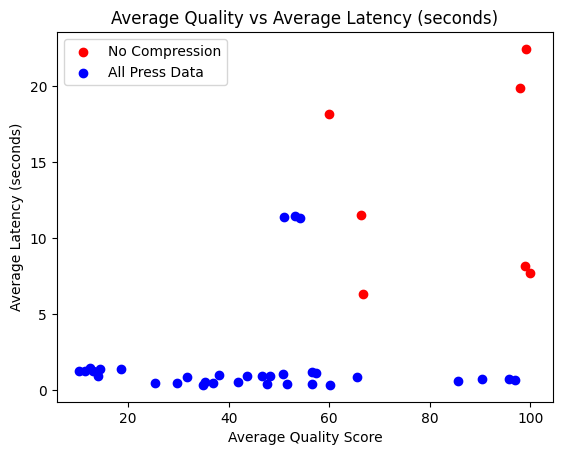

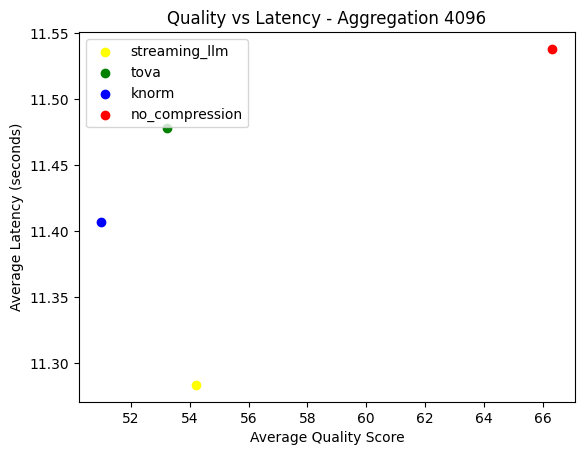

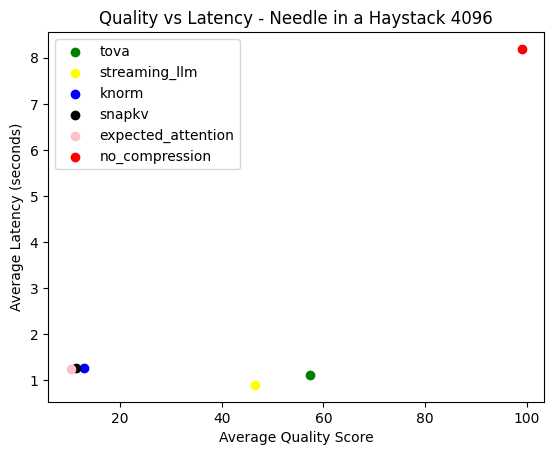

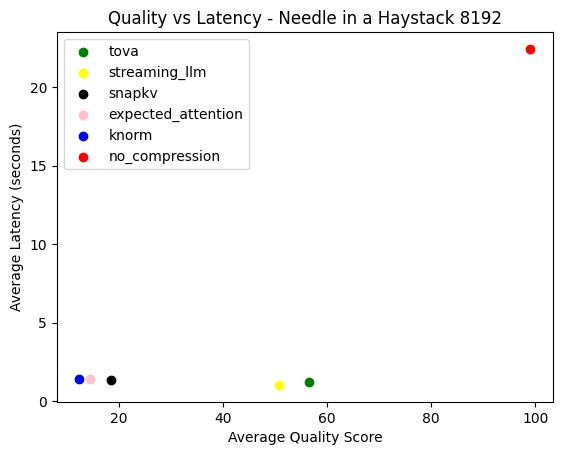

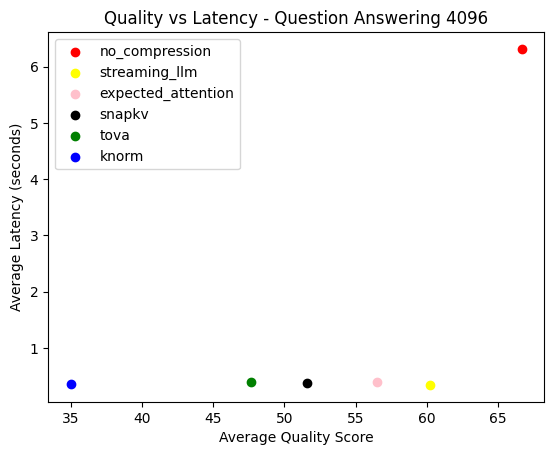

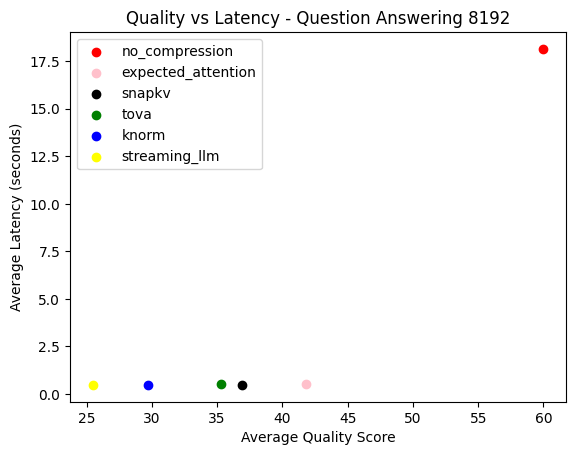

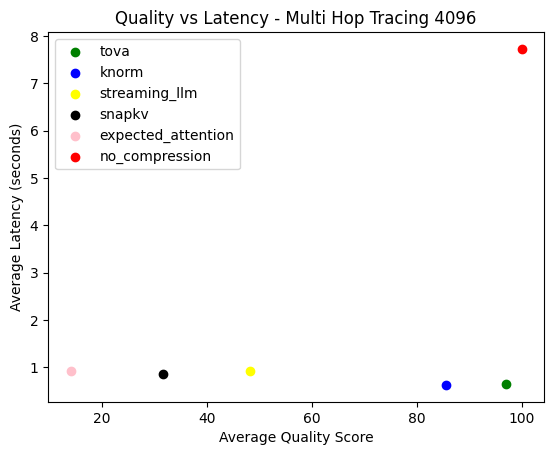

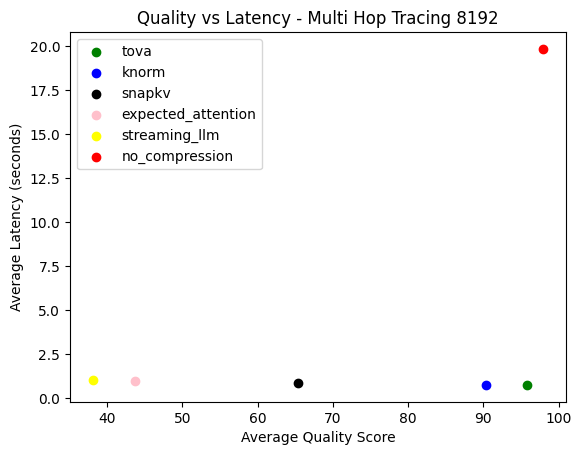

In [ ]:
## create a scatter plot that represents the quality score compared to latency ALL DATA

import matplotlib.pyplot as plt

if 'leaderboard' in globals() and not leaderboard.empty:
    scenarios = ['cwe,fwe', 'niah', 'qa', 'vt']
    scenarios_dict = {
        'cwe,fwe': 'Aggregation',
        'niah': 'Needle in a Haystack',
        'qa': 'Question Answering',
        'vt': 'Multi Hop Tracing'
    }

    methods_dict = {
        'no_compression': 'red',
        'knorm': 'blue',
        'tova': 'green',
        'streaming_llm': 'yellow',
        'snapkv': 'black',
        "expected_attention": "pink"
    }
    data_size = [4096, 8192]

    all_data = leaderboard.loc[:, ["avg_quality", "avg_latency_seconds", "method", "task_prefixes", "data_dir"]]

    baseline = all_data[all_data["method"] == "no_compression"]
    presses = all_data[all_data["method"] != "no_compression"]

    plt.scatter(baseline["avg_quality"], baseline["avg_latency_seconds"], c="red", label="No Compression")
    plt.scatter(presses["avg_quality"], presses["avg_latency_seconds"], c="blue", label="All Press Data")
    plt.legend()
    plt.title("Average Quality vs Average Latency (seconds)")
    plt.xlabel("Average Quality Score")
    plt.ylabel("Average Latency (seconds)")
    plt.show()

    for scenario in scenarios:
        scenario_data = all_data[all_data["task_prefixes"] == scenario]
        for data in data_size:
            if scenario == "cwe,fwe" and data == 8192:
                continue
            else:
                size_data = scenario_data[scenario_data["data_dir"] == data]
                for index, rows in size_data.iterrows():
                    plt.scatter(rows["avg_quality"], rows["avg_latency_seconds"], c=methods_dict[rows["method"]], label=rows["method"])

                plt.xlabel("Average Quality Score")
                plt.ylabel("Average Latency (seconds)")
                plt.title("Quality vs Latency - " + scenarios_dict[scenario] + " " + str(data))
                plt.legend()
                plt.show()

else:
    print('Load leaderboard')